In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

np.random.seed(42)
N = 2000
X = np.random.uniform(-3, 3, (N, 3))
x1 = X[:, 0]
x2 = X[:, 1]
x3 = X[:, 2]

# Deterministic nonlinear function
Y = np.sin(x1) + x2**2 + np.log(1 + np.abs(x3)) + 0.5 * x1 * x3
Y = Y.reshape(-1, 1)

print(f"X shape: {X.shape}")
print(f"Y shape: {Y.shape}")

X shape: (2000, 3)
Y shape: (2000, 1)


In [2]:
import tensorflow as tf

X_tf = tf.constant(X, dtype=tf.float32)
Y_tf = tf.constant(Y, dtype=tf.float32)

W1 = tf.Variable(tf.random.normal([3, 64], stddev=0.1))
b1 = tf.Variable(tf.zeros([64]))
W2 = tf.Variable(tf.random.normal([64, 32], stddev=0.1))
b2 = tf.Variable(tf.zeros([32]))
W3 = tf.Variable(tf.random.normal([32, 1], stddev=0.1))
b3 = tf.Variable(tf.zeros([1]))

optimizer = tf.keras.optimizers.Adam(learning_rate=0.01)

epochs = 1000
losses = []

for epoch in range(epochs):
    with tf.GradientTape() as tape:
        # We explicitly use tf.einsum to demonstrate matrix multiplication dimensions
        # 'ij,jk->ik' maps (batch, input_dim) @ (input_dim, output_dim) -> (batch, output_dim)
        # This completely avoids tf.matmul while keeping tensor interactions strictly defined.
        Z1 = tf.einsum('ij,jk->ik', X_tf, W1) + b1
        A1 = tf.nn.relu(Z1)

        Z2 = tf.einsum('ij,jk->ik', A1, W2) + b2
        A2 = tf.nn.relu(Z2)

        Z3 = tf.einsum('ij,jk->ik', A2, W3) + b3
        A3 = Z3 # Linear configuration for our nonlinear regression final layer

        loss = tf.reduce_mean(tf.square(A3 - Y_tf))

    grads = tape.gradient(loss, [W1, b1, W2, b2, W3, b3])
    optimizer.apply_gradients(zip(grads, [W1, b1, W2, b2, W3, b3]))

    losses.append(loss.numpy())
    if (epoch + 1) % 100 == 0:
        print(f"Epoch {epoch+1}/{epochs} - Loss: {loss.numpy():.4f}")

predictions = A3.numpy()

Epoch 100/1000 - Loss: 0.6446
Epoch 200/1000 - Loss: 0.5703
Epoch 300/1000 - Loss: 0.5529
Epoch 400/1000 - Loss: 0.5415
Epoch 500/1000 - Loss: 0.1531
Epoch 600/1000 - Loss: 0.1049
Epoch 700/1000 - Loss: 0.0868
Epoch 800/1000 - Loss: 0.0750
Epoch 900/1000 - Loss: 0.0662
Epoch 1000/1000 - Loss: 0.0580


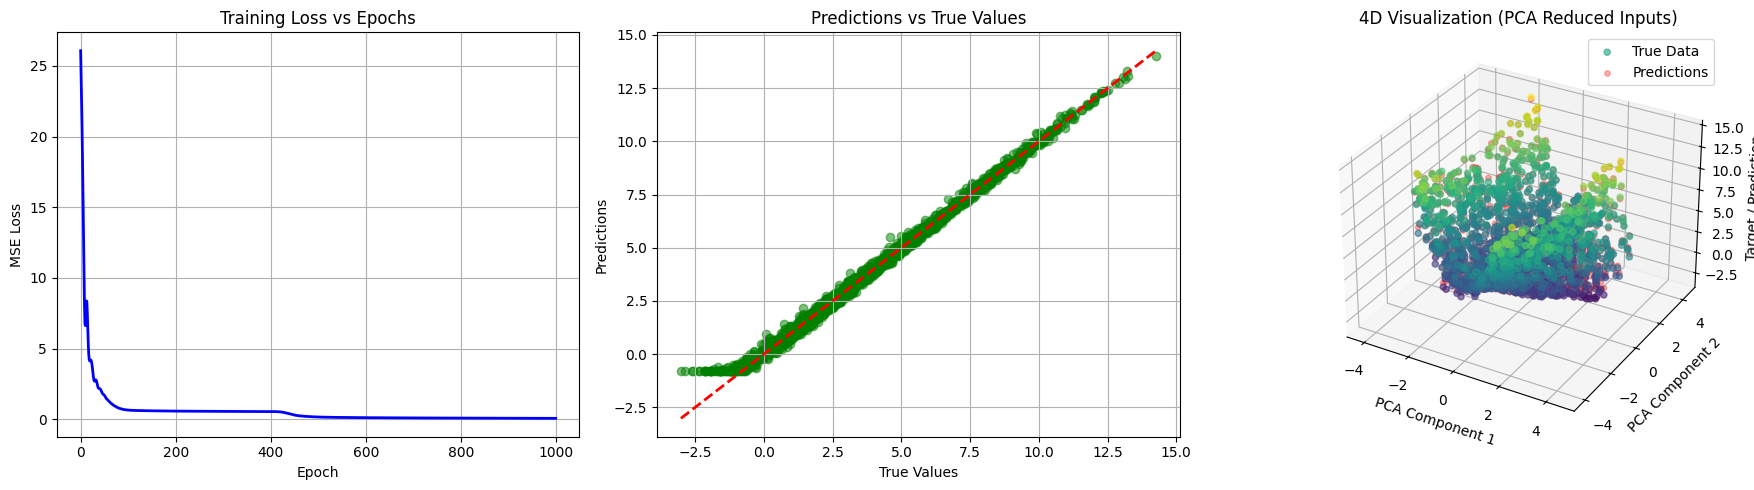

In [3]:
fig = plt.figure(figsize=(18, 5))

# Plot 1: Loss vs Epochs
ax1 = fig.add_subplot(1, 3, 1)
ax1.plot(losses, color='blue', linewidth=2)
ax1.set_title("Training Loss vs Epochs")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("MSE Loss")
ax1.grid(True)

# Plot 2: Predictions vs True Values
ax2 = fig.add_subplot(1, 3, 2)
ax2.scatter(Y, predictions, alpha=0.5, color='green')
ax2.plot([Y.min(), Y.max()], [Y.min(), Y.max()], 'r--', lw=2)
ax2.set_title("Predictions vs True Values")
ax2.set_xlabel("True Values")
ax2.set_ylabel("Predictions")
ax2.grid(True)

# Plot 3: 4D Visualization using PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

ax3 = fig.add_subplot(1, 3, 3, projection='3d')
sc = ax3.scatter(X_pca[:, 0], X_pca[:, 1], Y.flatten(), c=Y.flatten(), cmap='viridis', alpha=0.6, label='True Data')
ax3.scatter(X_pca[:, 0], X_pca[:, 1], predictions.flatten(), color='red', alpha=0.3, s=15, label='Predictions')
ax3.set_title("4D Visualization (PCA Reduced Inputs)")
ax3.set_xlabel("PCA Component 1")
ax3.set_ylabel("PCA Component 2")
ax3.set_zlabel("Target / Prediction")
ax3.legend()

plt.tight_layout()
plt.show()
